# L=32 XY — PC1–PC2 radius-only clustering comparison

This notebook makes the narrowest possible ring-aware comparison. For both raw-spin PCA and the matched cos/sin-channel frozen ResNet representation, the **only** clustering coordinate is

$$r_{12}=\sqrt{\mathrm{PC1}^2+\mathrm{PC2}^2}.$$

PCs 3–40, temperature, magnetization, and global spin angle are excluded from clustering. Both models use the same 410,000 balanced fit observations, exact Lloyd K-means settings, and 5,125 temperature-balanced silhouette observations. Temperature is consulted only afterward to name and plot the clusters.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score

OUT=Path('/home/lledson/senior-thesis/data/processed/xy32_broad/matched_all_bins')
N_RUNS,N_T,BINS=10_000,41,10
N_CONFIGS=N_RUNS*N_T*BINS
RATIOS=np.array([.60,.70,.78,.84,.87,.89,.90,.91,.92,.93,.94,.95,.96,.97,.98,.99,1.00,1.01,1.02,1.03,1.04,1.05,1.06,1.07,1.08,1.09,1.10,1.11,1.12,1.13,1.14,1.15,1.16,1.17,1.18,1.19,1.20,1.30,1.45,1.60,1.80])
temperature_ids=np.tile(np.repeat(np.arange(N_T,dtype=np.int8),BINS),N_RUNS)
fit_bins=(np.arange(N_RUNS)[:,None]+np.arange(N_T)[None,:])%BINS
FIT_INDICES=((np.arange(N_RUNS)[:,None]*N_T+np.arange(N_T)[None,:])*BINS+fit_bins).reshape(-1)
rng=np.random.default_rng(42)
EVAL_INDICES=[]
for ti in range(N_T):
    candidates=((np.arange(N_RUNS)*N_T+ti)*BINS)[:,None]+np.arange(BINS)
    EVAL_INDICES.append(rng.choice(candidates.ravel(),125,replace=False))
EVAL_INDICES=np.concatenate(EVAL_INDICES)

raw_scores=np.load(OUT/'raw_spin_pc1-40_scores.npy',mmap_mode='r')
res_scores=np.load(OUT/'resnet18_cossin_pc1-40_scores.npy',mmap_mode='r')

def radius(scores,indices):
    block=np.asarray(scores[indices,:2],dtype=np.float32)
    return np.sqrt(block[:,0]**2+block[:,1]**2)[:,None]

def radius_cluster(scores,prefix):
    fit_radius=radius(scores,FIT_INDICES)
    model=KMeans(2,random_state=42,n_init=10,max_iter=300,algorithm='lloyd').fit(fit_radius)
    path=OUT/f'{prefix}_pc12_radius_only_labels.npy'
    labels=np.lib.format.open_memmap(path,mode='w+',dtype=np.int8,shape=(N_CONFIGS,))
    for start in range(0,N_CONFIGS,100_000):
        stop=min(start+100_000,N_CONFIGS)
        labels[start:stop]=model.predict(radius(scores,slice(start,stop)))
    labels.flush(); unordered=np.asarray(labels)
    mean_ratios=[RATIOS[temperature_ids[unordered==k]].mean() for k in range(2)]
    order=np.argsort(mean_ratios); mapping=np.empty(2,dtype=np.int8); mapping[order[0]]=0; mapping[order[1]]=1
    labels[:]=mapping[unordered]; labels.flush(); aligned=np.asarray(labels)
    centers=np.empty(2,dtype=float)
    for original in range(2): centers[mapping[original]]=model.cluster_centers_[original,0]
    pop=np.stack([(aligned.reshape(N_RUNS,N_T,BINS)==k).mean((0,2)) for k in range(2)])
    all_radius=np.sqrt(np.asarray(scores[:,0],dtype=np.float32)**2+np.asarray(scores[:,1],dtype=np.float32)**2)
    shaped=all_radius.reshape(N_RUNS,N_T,BINS)
    seed_means=shaped.mean(2); radius_mean=seed_means.mean(0); radius_sem=seed_means.std(0,ddof=1)/np.sqrt(N_RUNS)
    diag={
        'method':'Exact sklearn KMeans (Lloyd) on PC1-PC2 radius only',
        'fit_observations':len(FIT_INDICES),'evaluation_size':len(EVAL_INDICES),
        'silhouette':float(silhouette_score(radius(scores,EVAL_INDICES),aligned[EVAL_INDICES])),
        'low_temperature_center_radius':float(centers[0]),'high_temperature_center_radius':float(centers[1]),
        'radius_midpoint_between_centers':float(centers.mean()),
        'low_endpoint_high_cluster_fraction':float(pop[1,0]),
        'at_TBKT_high_cluster_fraction':float(pop[1,16]),
        'high_endpoint_high_cluster_fraction':float(pop[1,-1]),
    }
    return labels,pop,radius_mean,radius_sem,diag

raw_labels,raw_pop,raw_mean,raw_sem,raw_diag=radius_cluster(raw_scores,'raw_spin')
res_labels,res_pop,res_mean,res_sem,res_diag=radius_cluster(res_scores,'resnet18_cossin')
ami=float(adjusted_mutual_info_score(raw_labels,res_labels))
comparison=pd.DataFrame({
    'representation':['Raw cos/sin PCA','Frozen ResNet-18: cos/sin channels'],
    'clustering coordinate':['sqrt(PC1^2 + PC2^2)','sqrt(PC1^2 + PC2^2)'],
    'silhouette':[raw_diag['silhouette'],res_diag['silhouette']],
    'low-T high-cluster fraction':[raw_diag['low_endpoint_high_cluster_fraction'],res_diag['low_endpoint_high_cluster_fraction']],
    'at TBKT high-cluster fraction':[raw_diag['at_TBKT_high_cluster_fraction'],res_diag['at_TBKT_high_cluster_fraction']],
    'high-T high-cluster fraction':[raw_diag['high_endpoint_high_cluster_fraction'],res_diag['high_endpoint_high_cluster_fraction']],
    'low-T center radius':[raw_diag['low_temperature_center_radius'],res_diag['low_temperature_center_radius']],
    'high-T center radius':[raw_diag['high_temperature_center_radius'],res_diag['high_temperature_center_radius']],
})
comparison['cross-representation AMI']=ami
comparison.to_csv(OUT/'xy32_pc12_radius_only_comparison.csv',index=False)
(OUT/'xy32_pc12_radius_only_diagnostics.json').write_text(json.dumps({'raw':raw_diag,'resnet_cossin':res_diag,'AMI':ami},indent=2))
comparison


,representation,clustering coordinate,silhouette,low-T high-cluster fraction,at TBKT high-cluster fraction,high-T high-cluster fraction,low-T center radius,high-T center radius,cross-representation AMI
0,Raw cos/sin PCA,sqrt(PC1^2 + PC2^2),0.717534,0.00000,0.00100,1.0000,20.904079,6.912922,0.208476
1,Frozen ResNet-18: cos/sin channels,sqrt(PC1^2 + PC2^2),0.572823,0.32004,0.33172,0.9992,6.416519,3.306959,0.208476


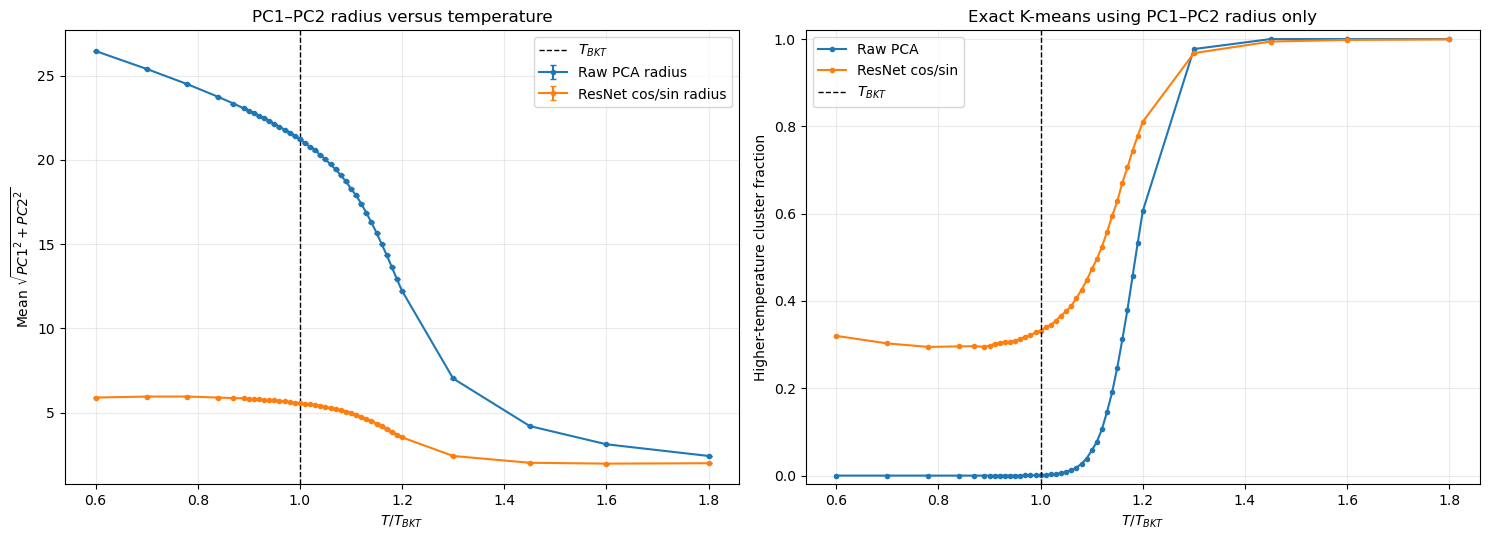

In [2]:
fig,axes=plt.subplots(1,2,figsize=(15,5.5))
axes[0].errorbar(RATIOS,raw_mean,yerr=raw_sem,fmt='o-',ms=3,capsize=2,label='Raw PCA radius')
axes[0].errorbar(RATIOS,res_mean,yerr=res_sem,fmt='o-',ms=3,capsize=2,label='ResNet cos/sin radius')
axes[0].axvline(1,color='black',ls='--',lw=1,label=r'$T_{BKT}$')
axes[0].set(xlabel=r'$T/T_{BKT}$',ylabel=r'Mean $\sqrt{PC1^2+PC2^2}$',title='PC1–PC2 radius versus temperature')
axes[0].grid(alpha=.25); axes[0].legend()

axes[1].plot(RATIOS,raw_pop[1],'o-',ms=3,label='Raw PCA')
axes[1].plot(RATIOS,res_pop[1],'o-',ms=3,label='ResNet cos/sin')
axes[1].axvline(1,color='black',ls='--',lw=1,label=r'$T_{BKT}$')
axes[1].set(xlabel=r'$T/T_{BKT}$',ylabel='Higher-temperature cluster fraction',title='Exact K-means using PC1–PC2 radius only',ylim=(-.02,1.02))
axes[1].grid(alpha=.25); axes[1].legend()
fig.tight_layout(); fig.savefig(OUT/'xy32_pc12_radius_only_comparison.png',dpi=220)
plt.show(); plt.close(fig)


## Interpretation

This is an intentionally restricted diagnostic, not a claim that ResNet PC1 and PC2 form an exact degenerate pair. It asks only whether the scalar radial magnitude of the leading two-PC plane carries comparable temperature structure in the two representations. Differences in the radius scale are immaterial because K-means is fitted separately; the population curves, silhouette values, and cross-representation AMI provide the meaningful comparison.